
Testing OpenAI Connection...

Prompt chaining is a technique used in natural language processing (NLP) and AI model interactions, particularly with large language models like GPT. It involves creating a sequence of prompts where the output of one prompt is used as the input for the next. This method allows for more complex and nuanced interactions, enabling the model to build on previous responses and maintain context over multiple exchanges.

Here’s how prompt chaining typically works:

1. **Initial Prompt**: Start with a prompt that sets the context or asks a specific question.
2. **Response Generation**: The model generates a response based on the initial prompt.
3. **Follow-up Prompt**: Use the model's response as part of a new prompt to ask a related question or to delve deeper into the topic.
4. **Iterative Process**: Repeat the process, chaining together multiple prompts and responses to explore a subject in greater depth or to develop a more complex narrative.

This technique 

/Users/utsabchakraborty/Documents/Edureka_May2026/Backup_LG/venv/lib/python3.14/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


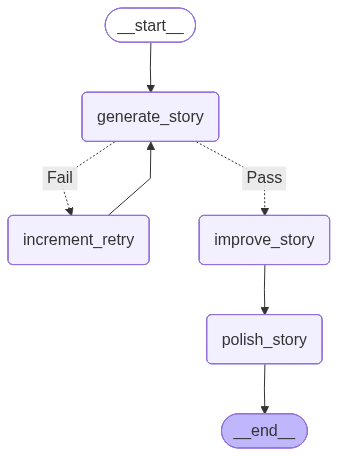



RUNNING PROMPT CHAINING WORKFLOW

--- GENERATE STORY NODE RUNNING ---
Topic: Electric Vehicles Market Assessment

Generated Story:

In a rapidly evolving landscape, a team of analysts uncovers hidden trends and consumer preferences that could redefine the electric vehicle market, igniting fierce competition among automakers.

--- VALIDATION NODE RUNNING ---
Retry Count: 0
Validation Passed

--- IMPROVE STORY NODE RUNNING ---

Improved Story:

**Enhanced Story Premise:**

In a world where the air is thick with the hum of innovation and the scent of change lingers like the first breath of spring, a team of analysts finds themselves at the heart of a revolution. As they sift through mountains of data, their screens flicker with the pulse of hidden trends and unspoken consumer desires, each statistic a heartbeat in the burgeoning electric vehicle market. The atmosphere is electric, charged with the promise of a future where the roar of combustion engines is replaced by the whisper of cle

KeyboardInterrupt: 

In [4]:
"""
====================================================================
LANGGRAPH PROMPT CHAINING WORKFLOW (OPENAI VERSION)
====================================================================

CONCEPTS TAUGHT:
----------------
1. Prompt Chaining
2. Sequential LLM Workflows
3. Multi-Step Reasoning
4. Stateful Graph Execution
5. Conditional Routing
6. Validation Loops
7. Shared Graph State
8. Node-Based AI Workflows
9. Dynamic Retry Mechanisms
10. Workflow Orchestration
11. Prompt Engineering Pipelines
12. Iterative Refinement
13. Enterprise AI Pipelines
14. Observability & Streaming
15. LangGraph Fundamentals

WHAT IS PROMPT CHAINING?
------------------------
Prompt chaining breaks a complex task into
multiple smaller prompts.

Instead of:
    One giant prompt

We use:
    Multiple smaller prompts

Each prompt:
- performs one task
- improves intermediate output
- passes output to next node

WHY PROMPT CHAINING?
--------------------
Benefits:
- better control
- higher accuracy
- modular design
- easier debugging
- reusable workflows

WHY LANGGRAPH?
---------------
LangGraph makes prompt chaining easy because:
- nodes represent prompts/tasks
- edges represent execution flow
- state stores intermediate outputs
- conditional routing enables loops/retries

ARCHITECTURE TYPE:
------------------
Sequential Workflow with Conditional Retry Loop

WORKFLOW:
---------
Generate Story
      ↓
Validation Check
      ↓
Improve Story
      ↓
Polish Story
      ↓
Final Output

IMPORTANT CONCEPT:
------------------
This workflow demonstrates:
- sequential orchestration
- conditional edges
- retry loops
- stateful execution

"""

# ==============================================================
# STEP 1 — IMPORTS
# ==============================================================

import os

from dotenv import load_dotenv

# ==============================================================
# STEP 2 — LOAD ENV VARIABLES
# ==============================================================

load_dotenv()

if not os.getenv("OPENAI_API_KEY"):

    raise ValueError(
        "OPENAI_API_KEY missing in .env file"
    )

os.environ["OPENAI_API_KEY"] = os.getenv(
    "OPENAI_API_KEY"
)

# Optional LangSmith Tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv(
    "LANGCHAIN_PROJECT",
    "LangGraph-Prompt-Chaining"
)

os.environ["LANGCHAIN_TRACING_V2"] = os.getenv(
    "LANGCHAIN_TRACING_V2",
    "true"
)

os.environ["LANGCHAIN_API_KEY"] = os.getenv(
    "LANGCHAIN_API_KEY",
    ""
)

# ==============================================================
# STEP 3 — CREATE OPENAI LLM
# ==============================================================
# Using OpenAI model.
#
# Easier for workshops:
# - stable
# - fewer setup issues
# - cleaner teaching experience

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# ==============================================================
# STEP 4 — TEST LLM CONNECTION
# ==============================================================
# Always validate connectivity first.

print("\nTesting OpenAI Connection...\n")

try:

    test_result = llm.invoke(
        "What is Prompt Chaining?"
    )

    print(test_result.content)

except Exception as e:

    print("LLM Connection Error:", e)

# ==============================================================
# STEP 5 — DEFINE GRAPH STATE
# ==============================================================
# IMPORTANT CONCEPT:
#
# State is shared across all nodes.
#
# Nodes:
# - read state
# - compute updates
# - return updates
#
# State acts as:
# - memory
# - communication layer
# - workflow context

from typing_extensions import TypedDict

class State(TypedDict):

    # Input topic
    topic: str

    # Initial generated story
    story: str

    # Enhanced version
    improved_story: str

    # Final polished version
    final_story: str

    # Retry tracking
    retry_count: int

# ==============================================================
# STEP 6 — GENERATE STORY NODE
# ==============================================================
# FIRST STEP in prompt chain.
#
# This node:
# - creates raw draft
# - initializes workflow

def generate_story(state: State):

    """
    Generate initial story premise.
    """

    print("\n--- GENERATE STORY NODE RUNNING ---")

    topic = state["topic"]

    print(f"Topic: {topic}")

    response = llm.invoke(

        f"""
        Write a ONE sentence story premise about:

        {topic}

        REQUIREMENTS:
        - concise
        - vivid
        - coherent
        - no question marks
        - no exclamation marks
        """
    )

    print("\nGenerated Story:\n")

    print(response.content)

    return {

        "story": response.content
    }

# ==============================================================
# STEP 7 — VALIDATION NODE
# ==============================================================
# IMPORTANT CONCEPT:
#
# Conditional routing enables:
# - validation
# - retries
# - intelligent workflows
# - dynamic execution

def validate_story(state: State):

    """
    Validate generated story.
    """

    print("\n--- VALIDATION NODE RUNNING ---")

    story = state["story"]

    retry_count = state.get(
        "retry_count",
        0
    )

    print(f"Retry Count: {retry_count}")

    # ==========================================================
    # Example Validation Rules
    # ==========================================================

    if (
        "?" in story
        or
        "!" in story
    ):

        print("Validation Failed")

        # ======================================================
        # Infinite Loop Protection
        # ======================================================
        # Production systems require safeguards.

        if retry_count >= 3:

            print(
                "Maximum retries reached"
            )

            return "Pass"

        return "Fail"

    print("Validation Passed")

    return "Pass"

# ==============================================================
# STEP 8 — RETRY COUNTER NODE
# ==============================================================
# Tracks retry attempts.
#
# Useful for:
# - observability
# - debugging
# - workflow monitoring

def increment_retry(state: State):

    """
    Increment retry counter.
    """

    current_retry = state.get(
        "retry_count",
        0
    )

    new_retry = current_retry + 1

    print(
        f"\nRetry incremented to: {new_retry}"
    )

    return {

        "retry_count": new_retry
    }

# ==============================================================
# STEP 9 — IMPROVE STORY NODE
# ==============================================================
# SECOND STEP in prompt chain.
#
# Enhances initial draft.

def improve_story(state: State):

    """
    Improve story quality.
    """

    print("\n--- IMPROVE STORY NODE RUNNING ---")

    response = llm.invoke(

        f"""
        Enhance this story premise with:
        - emotional depth
        - vivid imagery
        - stronger atmosphere

        Story:
        {state['story']}
        """
    )

    print("\nImproved Story:\n")

    print(response.content)

    return {

        "improved_story":
        response.content
    }

# ==============================================================
# STEP 10 — POLISH STORY NODE
# ==============================================================
# FINAL STEP in prompt chain.
#
# Adds:
# - twist
# - refinement
# - creativity

def polish_story(state: State):

    """
    Add final polish and twist.
    """

    print("\n--- POLISH STORY NODE RUNNING ---")

    response = llm.invoke(

        f"""
        Add an unexpected but logical twist
        to this story premise.

        Story:
        {state['improved_story']}

        REQUIREMENTS:
        - maintain coherence
        - preserve flow
        - improve engagement
        """
    )

    print("\nFinal Story:\n")

    print(response.content)

    return {

        "final_story":
        response.content
    }

# ==============================================================
# STEP 11 — BUILD LANGGRAPH WORKFLOW
# ==============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)

workflow = StateGraph(State)

# ==============================================================
# STEP 12 — ADD NODES
# ==============================================================

workflow.add_node(
    "generate_story",
    generate_story
)

workflow.add_node(
    "increment_retry",
    increment_retry
)

workflow.add_node(
    "improve_story",
    improve_story
)

workflow.add_node(
    "polish_story",
    polish_story
)

# ==============================================================
# STEP 13 — ADD EDGES
# ==============================================================

workflow.add_edge(
    START,
    "generate_story"
)

# ==============================================================
# CONDITIONAL ROUTING
# ==============================================================
# VERY IMPORTANT LANGGRAPH CONCEPT
#
# Enables:
# - retries
# - branching
# - validation loops

workflow.add_conditional_edges(

    "generate_story",

    validate_story,

    {
        "Pass": "improve_story",

        "Fail": "increment_retry"
    }
)

# ==============================================================
# RETRY LOOP
# ==============================================================
# LangGraph naturally supports loops.

workflow.add_edge(
    "increment_retry",
    "generate_story"
)

# ==============================================================
# CONTINUE PROMPT CHAIN
# ==============================================================

workflow.add_edge(
    "improve_story",
    "polish_story"
)

workflow.add_edge(
    "polish_story",
    END
)

# ==============================================================
# STEP 14 — COMPILE GRAPH
# ==============================================================
# Converts graph definition
# into executable application.

app = workflow.compile()

# ==============================================================
# STEP 15 — VISUALIZE GRAPH
# ==============================================================

from IPython.display import (
    Image,
    display
)

try:

    display(

        Image(

            app.get_graph()
            .draw_mermaid_png()

        )
    )

except Exception as e:

    print(
        "Visualization Error:",
        e
    )

# ==============================================================
# STEP 16 — EXECUTE GRAPH
# ==============================================================

print("\n")
print("=" * 70)
print("RUNNING PROMPT CHAINING WORKFLOW")
print("=" * 70)

initial_state = {

    "topic":
    "Electric Vehicles Market Assessment",

    "story": "",

    "improved_story": "",

    "final_story": "",

    "retry_count": 0
}

final_state = app.invoke(
    initial_state
)

# ==============================================================
# STEP 17 — PRINT RESULTS
# ==============================================================

print("\n")
print("=" * 70)
print("INITIAL STORY")
print("=" * 70)

print(final_state["story"])

print("\n")
print("=" * 70)
print("IMPROVED STORY")
print("=" * 70)

print(final_state["improved_story"])

print("\n")
print("=" * 70)
print("FINAL POLISHED STORY")
print("=" * 70)

print(final_state["final_story"])

# ==============================================================
# STEP 18 — STREAM EXECUTION
# ==============================================================
# VERY IMPORTANT CONCEPT:
#
# stream() enables observability.
#
# Critical for debugging workflows.

print("\n")
print("=" * 70)
print("STREAMING EXECUTION")
print("=" * 70)

for event in app.stream(
    initial_state
):

    print(event)

# ==============================================================
# STEP 19 — IMPORTANT TEACHING SUMMARY
# ==============================================================
#
# WHAT THIS EXAMPLE TAUGHT:
#
# 1. Prompt Chaining
# 2. Sequential AI Workflows
# 3. Stateful Execution
# 4. Conditional Routing
# 5. Validation Loops
# 6. Retry Mechanisms
# 7. Multi-Step Refinement
# 8. Workflow Orchestration
# 9. Node-Based AI Design
# 10. Observability
#
# MOST IMPORTANT TAKEAWAY:
#
# Prompt chaining breaks complex tasks
# into smaller manageable stages.
#
# Each stage:
# - improves output
# - increases control
# - enables debugging
# - creates modular workflows
#
# WHY THIS MATTERS:
#
# Enterprise AI systems rarely use:
# "one giant prompt"
#
# Instead they use:
# - planning
# - refinement
# - validation
# - synthesis
#
# Prompt chaining is one of the most
# foundational enterprise AI patterns.
#